In [ ]:
import cv2
import numpy as np
def load_images(path1, path2, size=(300, 300)):
    img1=cv2.imread(path1,cv2.IMREAD_GRAYSCALE) 
    img2=cv2.imread(path2,cv2.IMREAD_GRAYSCALE)

    img1=cv2.resize(img1,size)
    img2=cv2.resize(img2,size)

    A=img1.astype(np.float64)
    B=img2.astype(np.float64)

    return A,B

A,B =load_images("eren.jpeg","luffy2.jpeg")

print("A shape:",A.shape)
print("B shape:",B.shape)
print("A min/max:",A.min(), A.max())
print("B min/max:",B.min(), B.max())







A shape: (300, 300)
B shape: (300, 300)
A min/max: 0.0 241.0
B min/max: 1.0 251.0


[1 3]
UA shape: (300, 300)
SA shape: (300,)
VAt shape: (300, 300)

Top 5 singular values of A: [48636.3699177   6029.22648125  4153.34595747  3367.88257215
  2829.06710234]
Top 5 singular values of B: [53906.47903184  6554.19512794  4827.5934732   3395.47886062
  3058.71449784]


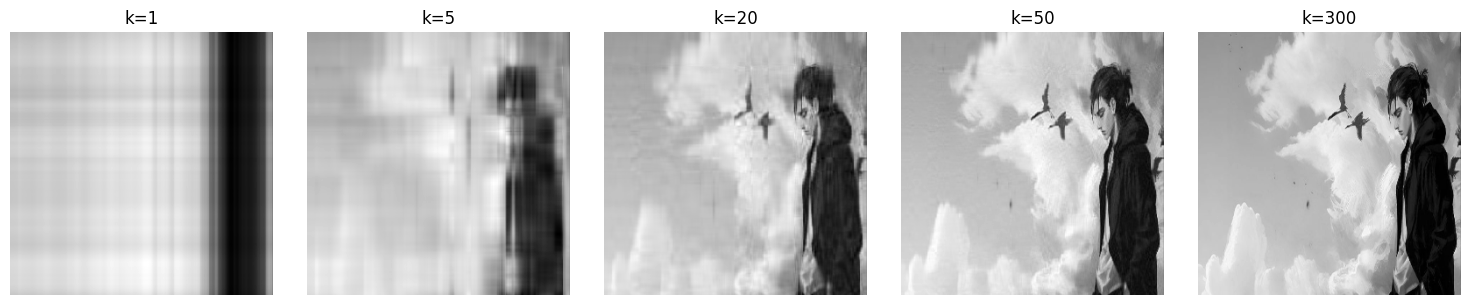

In [4]:

UA, SA, VAt = np.linalg.svd(A, full_matrices=False)
UB, SB, VBt = np.linalg.svd(B, full_matrices=False)
A=np.array([[1,2,3],[2,3,4]]);
print(np.diag(A));

import matplotlib.pyplot as plt

print("UA shape:", UA.shape)
print("SA shape:", SA.shape)
print("VAt shape:", VAt.shape)

print("\nTop 5 singular values of A:", SA[:5])
print("Top 5 singular values of B:", SB[:5])

def reconstruct(U, S, Vt, k):
    # take only top k
    Uk  = U[:, :k]
    Sk  = np.diag(S[:k])
    Vtk = Vt[:k, :]
    return Uk @ Sk @ Vtk
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
k_values = [1, 5, 20, 50, 300]

for ax, k in zip(axes, k_values):
    A_k = reconstruct(UA, SA, VAt, k)
    
    ax.imshow(A_k, cmap='gray')
    ax.set_title(f'k={k}')
    ax.axis('off')

plt.tight_layout()